In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 


seismic_data = pd.read_csv('C:/Users/SH/Desktop/cleaned_seismic.csv')
seismic_data.head()
print(seismic_data.columns)

Index(['Seismic Zone', 'PGA (m/s²)', 'PGV (m/s)', 'PGD (m)',
       'Spectral Acceleration (g)', 'Soil Type', 'Site Amplification Factor',
       'Historical Earthquake Magnitude (Mw)', 'Fault Distance (km)',
       'Seismic Wave Frequency (Hz)', 'Building Height (m)',
       'Number of Stories', 'Structural Material', 'Foundation Type',
       'Natural Frequency (Hz)', 'Damping Ratio (%)', 'Mass of Structure (kg)',
       'Axial Stiffness (kN/m)', 'Bending Stiffness (kN·m²)',
       'Lateral Load Resisting System',
       'Predicted Max Inter-Story Drift Ratio (%)',
       'Predicted Max Roof Displacement (m)',
       'Predicted Base Shear Force (kN)',
       'Predicted Structural Acceleration (m/s²)',
       'Predicted Damage Index (0–1 Scale)',
       'Predicted Collapse Probability (%)', 'damage_index', 'collapse_prob',
       'collapse_risk'],
      dtype='object')


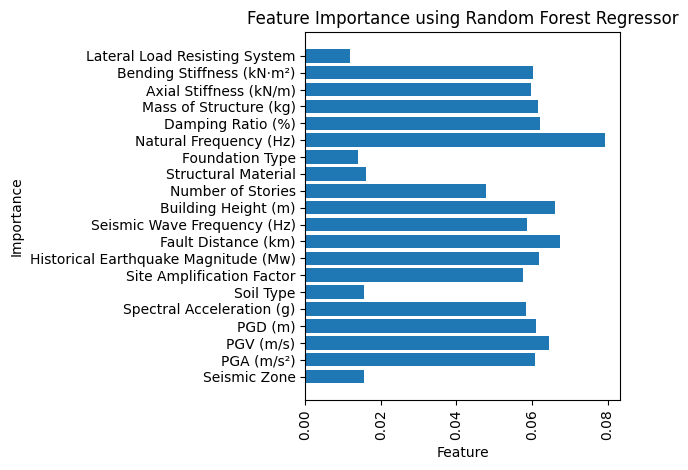

In [2]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

x = seismic_data.drop(columns = ['Predicted Max Inter-Story Drift Ratio (%)','Predicted Max Roof Displacement (m)', 'Predicted Base Shear Force (kN)',
                                 'Predicted Structural Acceleration (m/s²)','Predicted Damage Index (0–1 Scale)','Predicted Collapse Probability (%)', 
                                 'damage_index', 'collapse_prob','collapse_risk'])
y = seismic_data['damage_index']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

randomforest = RandomForestRegressor(n_estimators = 500, random_state = 42)
randomforest.fit(x_train, y_train)

important_rf = randomforest.feature_importances_
feature_names = x.columns

plt.barh(feature_names, important_rf)
plt.xticks(rotation=90)
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Feature Importance using Random Forest Regressor')
plt.tight_layout()
plt.show()


In [3]:
importantfeatures_rf = pd.Series(important_rf, index=feature_names)
for_rf = importantfeatures_rf.sort_values(ascending=False).head(7)
print(for_rf)

Natural Frequency (Hz)                  0.079337
Fault Distance (km)                     0.067311
Building Height (m)                     0.066204
PGV (m/s)                               0.064572
Damping Ratio (%)                       0.062096
Historical Earthquake Magnitude (Mw)    0.061828
Mass of Structure (kg)                  0.061575
dtype: float64


In [6]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split, RandomizedSearchCV

x = seismic_data[['Natural Frequency (Hz)','Fault Distance (km)','Building Height (m)', 'PGV (m/s)','Damping Ratio (%)', 
                  'Historical Earthquake Magnitude (Mw)', 'Mass of Structure (kg)']]
y = seismic_data['damage_index']  # continuous target

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

rf =RandomForestRegressor(random_state=42)

hyperparameters = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions= hyperparameters,
    n_iter=30,             
    scoring='r2',          
    cv=5,                  
    verbose=2,
    random_state=42,
    n_jobs=-1              
)

random_search.fit(x_train, y_train)


best_rf = random_search.best_estimator_
rf_pred = best_rf.predict(x_test)

print("Best Parameters Found:", random_search.best_params_)
print(f"R² Score: {r2_score(y_test, rf_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, rf_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, rf_pred)):.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters Found: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 5, 'bootstrap': True}
R² Score: -0.0113
MAE: 0.2495
RMSE: 0.2863


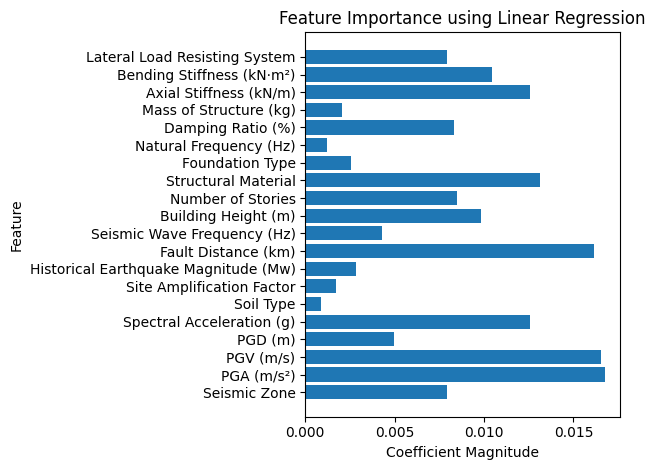

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

x = seismic_data.drop(columns=[
    'Predicted Max Inter-Story Drift Ratio (%)', 'Predicted Max Roof Displacement (m)', 
    'Predicted Base Shear Force (kN)', 'Predicted Structural Acceleration (m/s²)',
    'Predicted Damage Index (0–1 Scale)', 'Predicted Collapse Probability (%)', 
    'damage_index', 'collapse_prob', 'collapse_risk'
])
y = seismic_data['damage_index']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

linreg = LinearRegression()
linreg.fit(x_train, y_train)

importance_lin = np.abs(linreg.coef_)
feature_names = x.columns

plt.barh(feature_names, importance_lin)
plt.xlabel('Coefficient Magnitude')
plt.ylabel('Feature')
plt.title('Feature Importance using Linear Regression')
plt.tight_layout()
plt.show()

In [10]:
importantfeatures_lin = pd.Series(importance_lin, index=feature_names)
for_lin = importantfeatures_lin.sort_values(ascending=False).head(7)
print(for_lin)

PGA (m/s²)                   0.016768
PGV (m/s)                    0.016547
Fault Distance (km)          0.016138
Structural Material          0.013137
Axial Stiffness (kN/m)       0.012564
Spectral Acceleration (g)    0.012545
Bending Stiffness (kN·m²)    0.010426
dtype: float64


In [13]:
from sklearn.linear_model import Ridge

x = seismic_data[['PGA (m/s²)','PGV (m/s)','Fault Distance (km)', 'Structural Material','Axial Stiffness (kN/m)', 
                  'Spectral Acceleration (g)', 'Bending Stiffness (kN·m²)']]
y = seismic_data['damage_index']  

x = pd.get_dummies(x, drop_first=True)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

lin = Ridge(random_state=42)
 
hyperparameters = {
    'alpha': np.logspace(-4, 4, 100),  # Regularization strength
    'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'saga']
}

random_search = RandomizedSearchCV(
    estimator=lin,
    param_distributions=hyperparameters,
    n_iter=30,              
    scoring='r2',           
    cv=5,                   
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(x_train, y_train)

best_lin = random_search.best_estimator_
lin_pred = best_lin.predict(x_test)

print("Best Parameters Found:", random_search.best_params_)
print(f"R² Score: {r2_score(y_test, lin_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, lin_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, lin_pred)):.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters Found: {'solver': 'sparse_cg', 'alpha': np.float64(2718.5882427329457)}
R² Score: -0.0122
MAE: 0.2493
RMSE: 0.2864


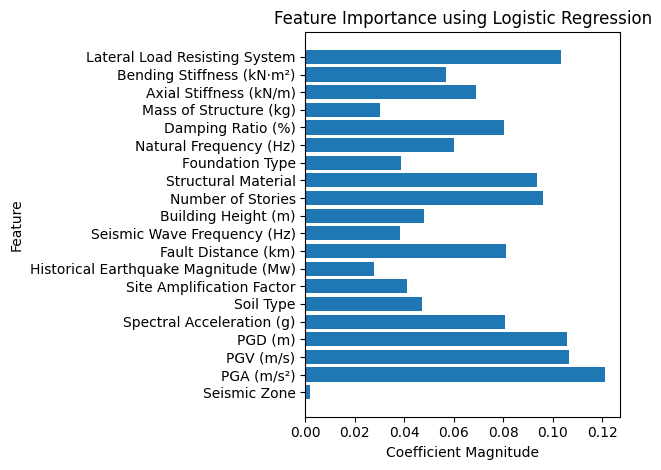

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

x = seismic_data.drop(columns=[
    'Predicted Max Inter-Story Drift Ratio (%)', 'Predicted Max Roof Displacement (m)', 
    'Predicted Base Shear Force (kN)', 'Predicted Structural Acceleration (m/s²)',
    'Predicted Damage Index (0–1 Scale)', 'Predicted Collapse Probability (%)', 
    'damage_index', 'collapse_prob', 'collapse_risk'
])

y = (seismic_data['damage_index'] > 0.5).astype(int)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(x_train, y_train)

importance_log = np.abs(logreg.coef_[0])
feature_names = x.columns

plt.barh(feature_names, importance_log)
plt.xlabel('Coefficient Magnitude')
plt.ylabel('Feature')
plt.title('Feature Importance using Logistic Regression')
plt.tight_layout()
plt.show()

In [ ]:
importantfeatures_log = pd.Series(importance_log, index=feature_names)
for_log = importantfeatures_log.sort_values(ascending=False).head(7)
print(for_log)

PGA (m/s²)                       0.121157
PGV (m/s)                        0.106572
PGD (m)                          0.105649
Lateral Load Resisting System    0.103204
Number of Stories                0.095924
Structural Material              0.093645
Fault Distance (km)              0.081158
dtype: float64


              precision    recall  f1-score   support

         Low       0.35      0.33      0.34        54
    Moderate       0.21      0.17      0.19        40
        High       0.13      0.11      0.12        44
   Very High       0.25      0.31      0.28        62

    accuracy                           0.24       200
   macro avg       0.23      0.23      0.23       200
weighted avg       0.24      0.24      0.24       200



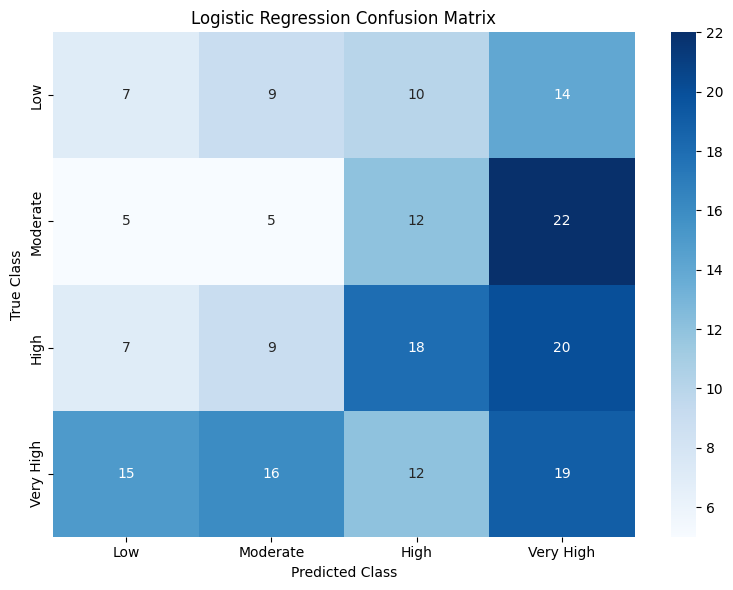

In [ ]:
bins = [0, 0.25, 0.5, 0.75, 1.0]
label_names = ['Low', 'Moderate', 'High', 'Very High']

x = seismic_data[['PGA (m/s²)','PGV (m/s)','PGD (m)', 'Lateral Load Resisting System',
                  'Number of Stories', 'Structural Material', 'Fault Distance (km)']]

y = pd.cut(seismic_data['damage_index'], bins=bins, labels=label_names, include_lowest=True)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(x_train, y_train)

log_pred = logreg.predict(x_test)

print(classification_report(y_test, log_pred, target_names=label_names))

cm = confusion_matrix(y_test, log_pred, labels=label_names)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Logistic Regression Confusion Matrix')
plt.tight_layout()
plt.show()


c:\Users\SH\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:34:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


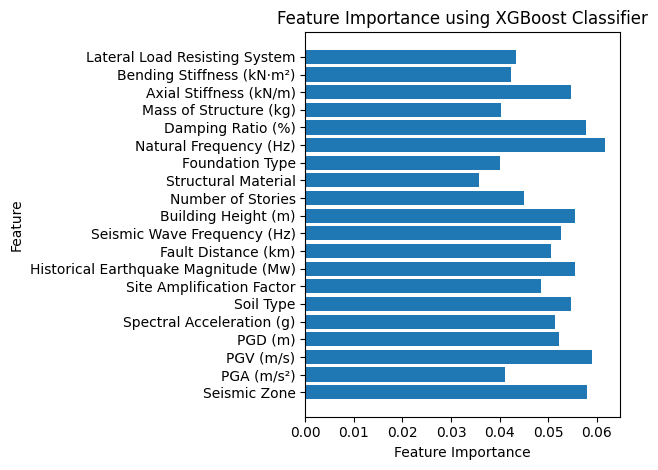

In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

x = seismic_data.drop(columns=[
    'Predicted Max Inter-Story Drift Ratio (%)', 'Predicted Max Roof Displacement (m)', 
    'Predicted Base Shear Force (kN)', 'Predicted Structural Acceleration (m/s²)',
    'Predicted Damage Index (0–1 Scale)', 'Predicted Collapse Probability (%)', 
    'damage_index', 'collapse_prob', 'collapse_risk'
])

y = (seismic_data['damage_index'] > 0.5).astype(int)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

model.fit(x_train, y_train)

importance_xgb = model.feature_importances_
feature_names = x.columns

plt.barh(feature_names, importance_xgb)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance using XGBoost Classifier')
plt.tight_layout()
plt.show()

In [ ]:
importantfeatures_xgb = pd.Series(importance_xgb, index=feature_names)
for_xgb = importantfeatures_xgb.sort_values(ascending=False).head(7)
print(for_xgb)

Natural Frequency (Hz)                  0.061675
PGV (m/s)                               0.058951
Seismic Zone                            0.058020
Damping Ratio (%)                       0.057729
Building Height (m)                     0.055584
Historical Earthquake Magnitude (Mw)    0.055553
Soil Type                               0.054714
dtype: float32


In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

x = seismic_data[['Natural Frequency (Hz)','PGV (m/s)','Seismic Zone', 'Damping Ratio (%)','Building Height (m)', 
                  'Historical Earthquake Magnitude (Mw)', 'Soil Type']]
y = seismic_data['damage_index'] 

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

param_dist = {
    'n_estimators': [200, 300, 500, 800],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 10],
    'min_child_weight': [1, 3, 5, 7],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_alpha': [0, 0.01, 0.1, 0.5],
    'reg_lambda': [0.5, 1, 1.5, 2],
    'booster': ['gbtree', 'dart']
}

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,             # number of random combinations
    scoring='r2',
    cv=5,
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(x_train, y_train)
best_xgb = random_search.best_estimator_
xgb_pred = best_xgb.predict(x_test)

print("Best Parameters:", random_search.best_params_)
print(f"R² Score: {r2_score(y_test, xgb_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, xgb_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, xgb_pred)):.4f}")


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 0.01, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.01, 'gamma': 0.3, 'colsample_bytree': 1.0, 'booster': 'gbtree'}
R² Score: 0.0006
MAE: 0.2475
RMSE: 0.2846


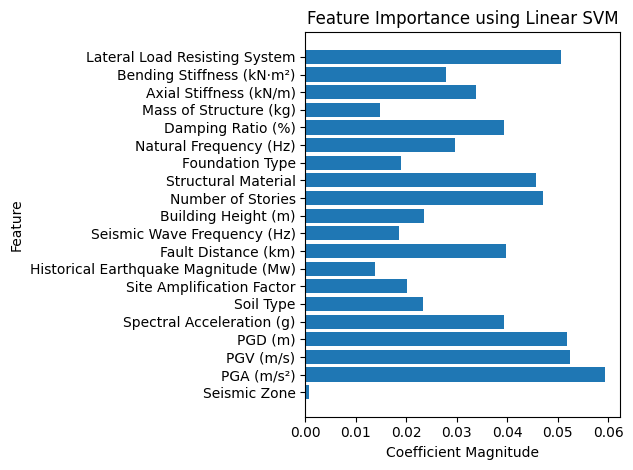

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# Prepare features
x = seismic_data.drop(columns=[
    'Predicted Max Inter-Story Drift Ratio (%)', 'Predicted Max Roof Displacement (m)', 
    'Predicted Base Shear Force (kN)', 'Predicted Structural Acceleration (m/s²)',
    'Predicted Damage Index (0–1 Scale)', 'Predicted Collapse Probability (%)', 
    'damage_index', 'collapse_prob', 'collapse_risk'
])

# Binary target: damage_index > 0.5
y = (seismic_data['damage_index'] > 0.5).astype(int)

# Split data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Initialize linear SVM
svm = LinearSVC(max_iter=10000, random_state=42)
svm.fit(x_train, y_train)

# Get absolute value of coefficients as feature importance
importance_svm = np.abs(svm.coef_[0])
feature_names = x.columns

# Plot feature importances
plt.barh(feature_names, importance_svm)
plt.xlabel('Coefficient Magnitude')
plt.ylabel('Feature')
plt.title('Feature Importance using Linear SVM')
plt.tight_layout()
plt.show()

In [ ]:
importantfeatures_svm = pd.Series(importance_svm, index=feature_names)
for_svm = importantfeatures_svm.sort_values(ascending=False).head(7)
print(for_svm)

PGA (m/s²)                       0.059316
PGV (m/s)                        0.052296
PGD (m)                          0.051705
Lateral Load Resisting System    0.050587
Number of Stories                0.047063
Structural Material              0.045635
Fault Distance (km)              0.039642
dtype: float64


In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


x = seismic_data[['PGA (m/s²)','PGV (m/s)','PGD (m)', 'Lateral Load Resisting System','Number of Stories', 
                  'Structural Material', 'Fault Distance (km)']]
y = seismic_data['damage_index']  # continuous target


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

categorical = ['Lateral Load Resisting System', 'Structural Material']
numeric = [col for col in x.columns if col not in categorical]

# --- Preprocessing ---
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric),
        ('cat', OneHotEncoder(drop='first'), categorical)
    ]
)

# --- SVR model ---
svr = SVR()

# --- Pipeline (Preprocessing + Model) ---
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', svr)
])

# --- Hyperparameter Search Space ---
param_dist = {
    'model__kernel': ['rbf', 'poly', 'sigmoid'],
    'model__C': [0.1, 1, 10, 100],
    'model__epsilon': [0.01, 0.05, 0.1, 0.2],
    'model__gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'model__degree': [2, 3, 4],
    'model__coef0': [0.0, 0.5, 1.0]
}

# --- Randomized Search (faster than grid search) ---
search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

# --- Fit search ---
search.fit(x_train, y_train)
print("Best Parameters:", search.best_params_)

# --- Evaluate best model ---
best_svr = search.best_estimator_
svm_pred = best_svr.predict(x_test)

print("\nSVM Regression Results:")
print(f"R² Score: {r2_score(y_test, svm_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, svm_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, svm_pred)):.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'model__kernel': 'rbf', 'model__gamma': 0.01, 'model__epsilon': 0.1, 'model__degree': 3, 'model__coef0': 0.0, 'model__C': 0.1}

SVM Regression Results:
R² Score: -0.0415
MAE: 0.2514
RMSE: 0.2905


In [ ]:
bins = [0, 0.25, 0.5, 0.75, 1.0]
label_names = ['Low', 'Moderate', 'High', 'Very High']

y_test_clipped = np.clip(y_test, 0, 1)
svm_pred_clipped = np.clip(svm_pred, 0, 1)
xgb_pred_clipped = np.clip(xgb_pred, 0, 1)


y_test_classes = np.digitize(y_test_clipped, bins, right=True) - 1
svm_pred_classes = np.digitize(svm_pred_clipped, bins, right=True) - 1
xgb_pred_classes = np.digitize(xgb_pred_clipped, bins, right=True) - 1

y_test_classes = np.clip(y_test_classes, 0, len(bins) - 2)
svm_pred_classes = np.clip(svm_pred_classes, 0, len(bins) - 2)
xgb_pred_classes = np.clip(xgb_pred_classes, 0, len(bins) - 2)

XGBoost Classification Report:
[[ 0 11 29  0]
 [ 0 17 27  0]
 [ 0 13 41  0]
 [ 0 14 48  0]]
              precision    recall  f1-score   support

         Low       0.00      0.00      0.00        40
    Moderate       0.31      0.39      0.34        44
        High       0.28      0.76      0.41        54
   Very High       0.00      0.00      0.00        62

    accuracy                           0.29       200
   macro avg       0.15      0.29      0.19       200
weighted avg       0.14      0.29      0.19       200



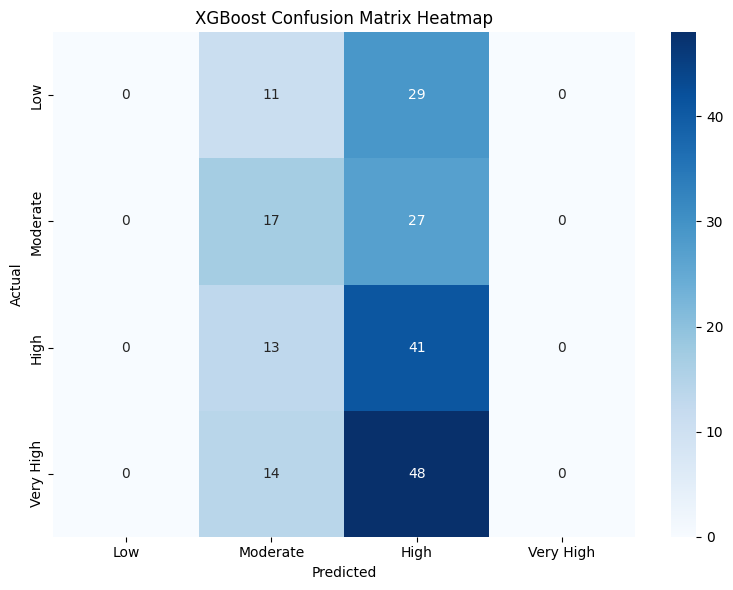

In [ ]:
print("XGBoost Classification Report:")

# Compute confusion matrix
cm = confusion_matrix(y_test_classes, xgb_pred_classes)
print(cm)

# Print classification report
print(classification_report(
    y_test_classes,
    xgb_pred_classes,
    labels=[0, 1, 2, 3],
    target_names=label_names,
    zero_division=0
))

# Plot confusion matrix heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost Confusion Matrix Heatmap')
plt.tight_layout()
plt.show()


SVM Classification Report:
[[ 0  8 32  0]
 [ 0  6 38  0]
 [ 0 12 42  0]
 [ 0 21 41  0]]
              precision    recall  f1-score   support

         Low       0.00      0.00      0.00        40
    Moderate       0.13      0.14      0.13        44
        High       0.27      0.78      0.41        54
   Very High       0.00      0.00      0.00        62

    accuracy                           0.24       200
   macro avg       0.10      0.23      0.13       200
weighted avg       0.10      0.24      0.14       200



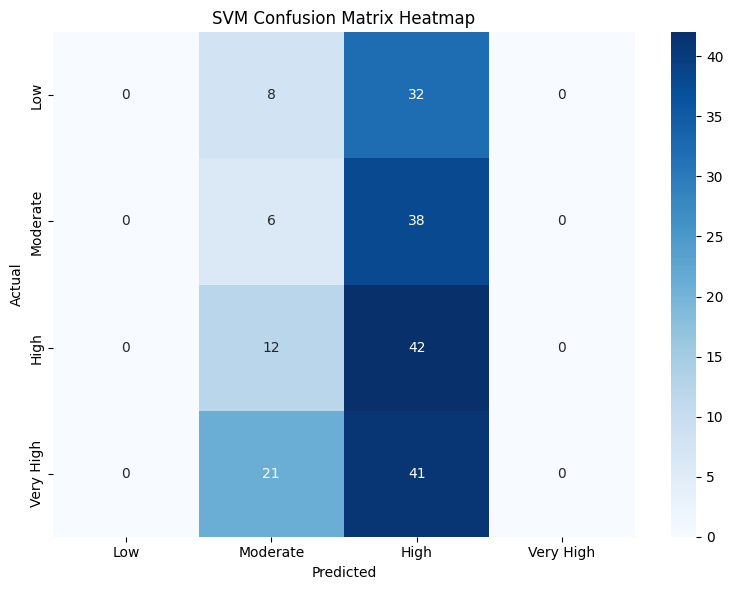

In [ ]:
print("\nSVM Classification Report:")
cm = confusion_matrix(y_test_classes, svm_pred_classes)
print(cm)
print(classification_report(
    y_test_classes,
    svm_pred_classes,
    labels=[0, 1, 2, 3],
    target_names=label_names,
    zero_division=0
))

# Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Confusion Matrix Heatmap')
plt.tight_layout()
plt.show()